<a href="https://colab.research.google.com/github/minaGalil/Imperial-Capstone/blob/main/Self_study_Try_it_15_1_Applying_different_activation_functions_in_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 15.1: Applying different activation functions in a neural network

Cybenko’s work provides the foundational proof for the Universal Approximation Theorem in neural networks. In his 1989 paper, George Cybenko showed that a feedforward neural network with a single hidden layer and a sufficient number of neurons, when using a continuous sigmoidal activation function, can approximate any continuous function defined on a compact subset of real numbers. This result established that such neural networks are universal function approximators, capable of representing a wide range of functions with high accuracy, given enough hidden units.

In this Self-Study Try-It activity you will get familiariazed with the following:-

1. The different activiations functions
2. Function approximations by superimposing two functions

Let us first start with the different activation functions

In [1]:
#import necessary libraries

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt



Let us first plot a logistic function in Python and get familiar with how the shape of the function changes as you change the weight.

## Activation functions

The basic activation functions which will be seen here are

a. Sigmoid Function

b. Modified Sigmoidal Function

c. ReLU(Rectifier Linear Unit)

d. Leaky ReLU

e. Softplus

### a. Sigmoid Function

The sigmoid function takes the "S" shape. There are several functions that give a sigmoid function, but typically in neural networks, when we refer to *the* sigmoid function we mean the logistic function, which is:
$$s(z) := \dfrac{1}{1 + e^{-z}}.$$
Let us plot this function for several values of $z$ and see why we have the S-shape.

In [2]:
#Define the sigmoid function
def sigmoid(z):
    """The sigmoid function."""
    return 1.0/(1.0 + np.exp(-z))
#generic plot function
def plot_function(f, x):
    plt.plot(x, f(x))
    try:
        title = f.__name__
        plt.title('%s' % title)
        plt.savefig('%s.png' % title)
    except AttributeError as e:
        print(e)
    plt.show()

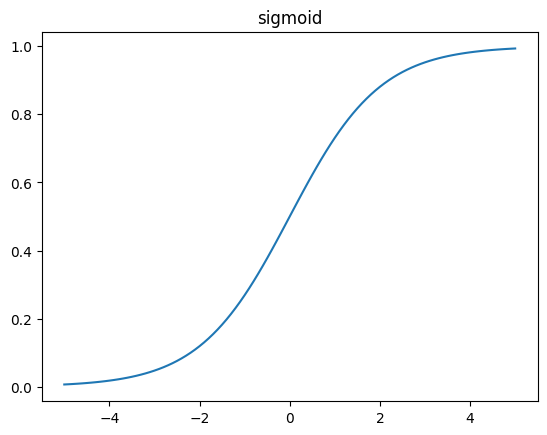

In [3]:
jump = .1
x = np.arange(-5., 5 + jump, jump) #Generate x = -5, -5 + 0.1, -5 + 2 * 0.1, ..., 5 (jump = 0.1 gives 0.1 jumps!)

plot_function(sigmoid, x)

## To-Do:
Generate a NumPy array of `x` values ranging from `-50` to `50` (inclusive or exclusive of last point, depending on your intent), with steps (jumps) of 0.1.

In [4]:
# Type your code here
jump = 0.1
x = np.arange(-50., 50 + jump, jump)

In addition to the S-shape, we always obtain values that are within $[0,1]$. This is because the logistic function always takes values between $0$ and $1$. To see this, observe that as $z \rightarrow \infty$ we have $e^{-z}= 0$ hence $s(z) = 1$ and as $z \rightarrow 0$ we have $e^{-z} = \infty$ hence $s(z) = 0$.

Thanks to this property, we typically use the sigmoid function to come up with "probabilities" for an instance to belong to either of two classes in a standard classification setting, though there are many extensions possible.

We can shift and scale the sigmoid function which is the **modified_sigmoid** activation function.

### b. Modified sigmoid

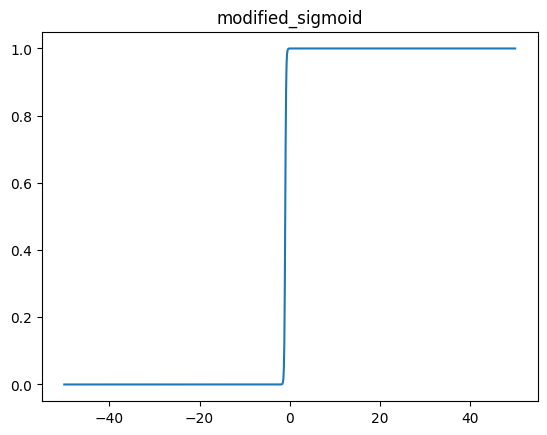

In [5]:
def modified_sigmoid(z):
    """The modified sigmoid function."""
    z = 10*z + 10
    return sigmoid(z)
plot_function(modified_sigmoid, x)

However, in neural networks we will not need to worry about which scaling or shifting to take, as the weights will be optimized in a way that the corresponding 'shape' of the sigmoid function will make the best predictions.

### c. ReLU (Rectified Linear Unit)
The ReLU function simply keeps the positive part of its argument:
$$r(x) = \max \{0, x\}. $$
Sometimes this function is referred as $\mathrm{ReLU(x)}$.

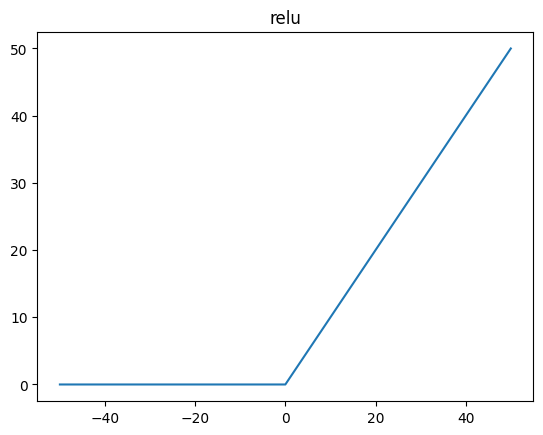

In [6]:
def relu(z):
    """The relu function."""
    return np.maximum(0,z)
plot_function(relu, x)

### d. Leaky ReLU
The Leaky ReLU function is simply changing the definition of ReLU slightly for negative inputs:

$$ rl(x) = \begin{cases}
x & \text{ if } x> 0 \\
0.01x & \text{ otherwise.}
\end{cases}$$

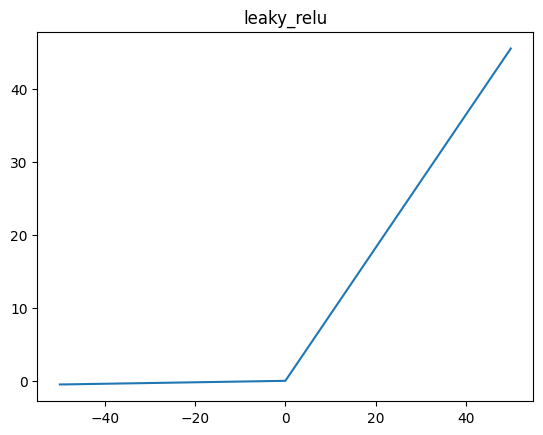

In [7]:
def leaky_relu(z): # Custom Leaky ReLU (0.9x / 0.01x) for better plot visibility

    """The leaky relu function."""
    return 0.01*z + 0.9*np.maximum(0,z)
plot_function(leaky_relu, x)

### e. Softplus
Smooth approximation of the ReLU function:
$$ sp(x) =  \log(1 + e^{x})$$

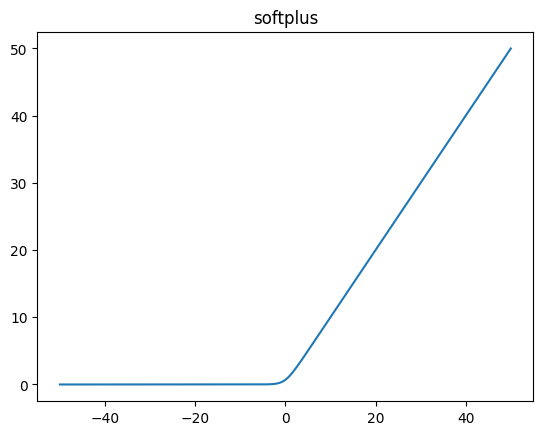

In [8]:
def softplus(z):
    """The sofplus function."""
    return np.log(1 + np.exp(z))
plot_function(softplus, x)

**To-Do:**

The Exponential linear unit (ELU) activation, for some $\alpha > 0$ is:
$$el(X) = \begin{cases} \alpha \cdot( e^x - 1) & \text{ if } x \leq 0 \\  x  & \text{ if } x > 0 \end{cases}.$$
Visualize this activation function for $\alpha = 1$.

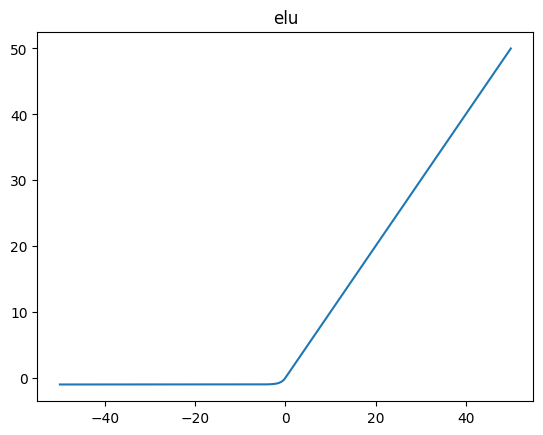

In [9]:
### Type your code here
def elu(z, alpha=1):
    """The Exponential Linear Unit (ELU) function."""
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

plot_function(elu, x)

## Shifts and scalings and function superposition

The shifts and scalings change the shape of a function, and the function superposition leads to new functions.

Consider how shifts and scalings change the shape of a function, and how function superposition leads to new functions.

In [10]:
# example of python closure
def shape_shift(f, w=1., b=0.):
    g = lambda x: f(w*x + b)
    return np.vectorize(g)

# to add 2 or more functions in python
# for function superposition
def add_functions(fs, ws):
    assert len(fs) == len(ws)
    _sum = lambda x: sum([w*f(x) for f, w in zip(fs, ws)])
    return _sum

Two functions are defined. These are functions `f1(x)` and `f2(x)`.
To superimpose two functions `f1(x)` and `f2(x)`
 and
 means to create a linear combination of them with the goal of achieving a third function:

 `f(x) = af1(x) + bf2(x)`



In [11]:
def f1(x):
    return x

def f2(x):
    return x**2


In [12]:
# Define your coefficients
a = 2  # coefficient for f1
b = 3  # coefficient for f2

# Compose functions
fs = [f1, f2]
ws = [a, b]
f = add_functions(fs, ws)


### To-Do:

Evaluate the function, `f(x)` at x = 1, 2, 3

In [13]:
### Type your code here
x = 1
print(f(x))

x = 2
print(f(x))

x = 3
print(f(x))

5
16
33


### To-Do:

How do `w` and `b`, respectively, change the shape of the sigmoid function? Try, for example, (w,b) = (20., 0.), (20,-20) and see if you can notice a pattern for when the functions spike up.

Note:- `z = wx + b`

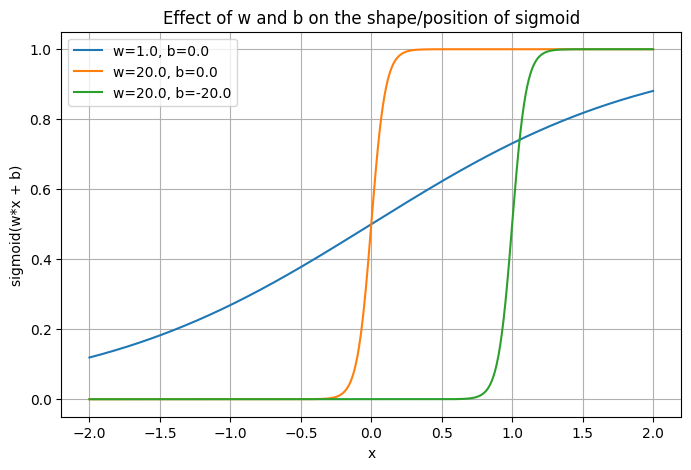

In [14]:
### Your solution
#def sigmoid(x, w=1.0, b=0.0):
def sigmoid(x, w=1.0, b=0.0):
    """Sigmoid with weight w and bias b: sigmoid(wx + b)."""
    z = w * x + b
    return 1.0 / (1.0 + np.exp(-z))


x = np.linspace(-2, 2, 1000)

# Try different (w, b) pairs
configs = [
    (1.0, 0.0),   # Standard sigmoid
    (20.0,  0.0), # Steep, spike at 0
    (20.0, -20.0) # Steep, spike at x=1
]

plt.figure(figsize=(8, 5))
for w, b in configs:
    y = sigmoid(x, w=w, b=b)
    plt.plot(x, y, label=f'w={w}, b={b}')

plt.xlabel("x")
plt.ylabel("sigmoid(w*x + b)")
plt.title("Effect of w and b on the shape/position of sigmoid")
plt.legend()
plt.grid(True)
plt.show()


### Answer: How w and b affect the sigmoid function σ(wx + b):



### To-Do:
Now take the functions (20., 0.) and (20., -20). Superimpose the two functions (add them) with weights 0.8 and -0.8 to create a new function. What does the new function look like?

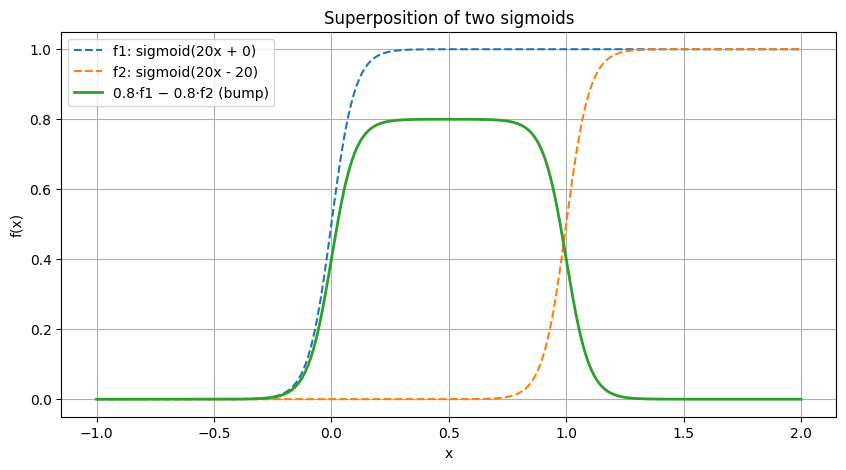

In [15]:
### your solution
# def sigmoid():
def sigmoid(x, w=1.0, b=0.0):
    z = w * x + b
    return 1.0 / (1.0 + np.exp(-z))

x = np.linspace(-1, 2, 1000)  # Narrower range to focus on shape between spikes

# Define the two functions
#f1
#f2
f1 = lambda x: sigmoid(x, w=20., b=0.)    # spikes at x=0
f2 = lambda x: sigmoid(x, w=20., b=-20.)  # spikes at x=1

# Define weights
w1 = 0.8
w2 = -0.8

# Superposition: f(x) = 0.8 * f1(x) - 0.8 * f2(x)
f_combined = lambda x: w1 * f1(x) + w2 * f2(x)

# Plot all three for comparison

plt.figure(figsize=(10, 5))
plt.plot(x, f1(x),          label='f1: sigmoid(20x + 0)',    linestyle='--')
plt.plot(x, f2(x),          label='f2: sigmoid(20x - 20)',   linestyle='--')
plt.plot(x, f_combined(x),  label='0.8·f1 − 0.8·f2 (bump)', linewidth=2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Superposition of two sigmoids")
plt.legend()
plt.grid(True)
plt.show()

### What does the function look like?

### Type in your answer.
A bump (hat) shape — it rises sharply near x=0 and falls back down near x=1, approximating a rectangular pulse. This is the key idea behind the Universal Approximation Theorem.

### To-Do:

Let's say you could first approximate a function as a step-wise constant function (in a staircase fashion). How would you then approximate it using sigmoid functions?

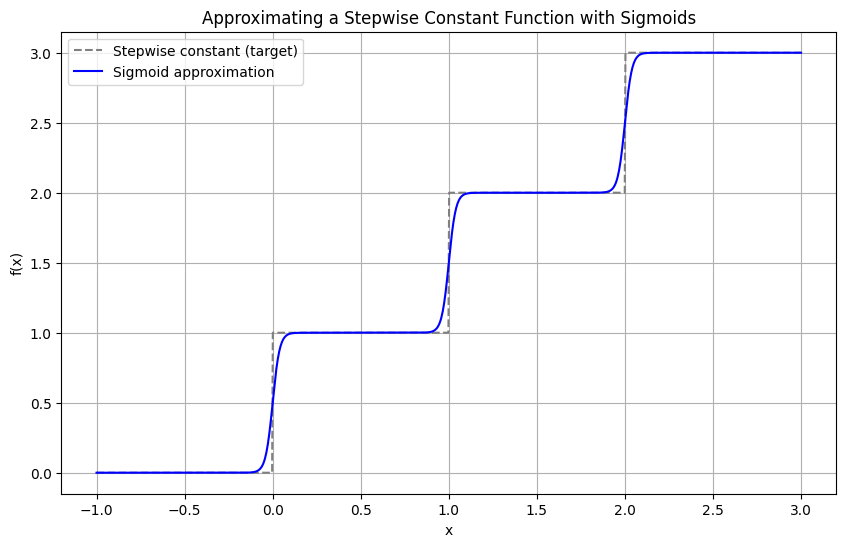

In [19]:
### Your solution

# def sigmoid():
def sigmoid(x, w=1.0, b=0.0):
    z = w * x + b
    return 1.0 / (1.0 + np.exp(-z))


x = np.linspace(-1, 3, 1000)

# Parameters for staircase: jumps at x=0, x=1, x=2; heights 1, 2, 3
#w
w = 50.0

# Heights of each step
#h1
#h2
#h3
h1 = 1  # step up by 1 at x=0
h2 = 1  # step up by 1 at x=1
h3 = 1  # step up by 1 at x=2

# Total height at each segment: 0, 1, 2, 3

# Each sigmoid starts at x0, x1, x2, etc.
#s1
#s2
#s3
s1 = sigmoid(x, w=w, b=0.)    # jumps at x=0  (b = -w*x_jump = 0)
s2 = sigmoid(x, w=w, b=-50.)  # jumps at x=1  (b = -w*1 = -50)
s3 = sigmoid(x, w=w, b=-100.) # jumps at x=2  (b = -w*2 = -100)

# The sum is a staircase: each sigmoid adds another level
#y_approx
y_approx = h1*s1 + h2*s2 + h3*s3

# Plot
plt.figure(figsize=(10, 6))

# Plot the original stepwise approximation for reference
plt.plot(x,
         np.piecewise(x, [x<0, (x>=0)&(x<1), (x>=1)&(x<2), x>=2], [0,1,2,3]),
         label="Stepwise constant (target)", color="gray", linestyle="dashed")

# Plot sigmoid approximation
plt.plot(x, y_approx, label="Sigmoid approximation", color="blue")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Approximating a Stepwise Constant Function with Sigmoids")
plt.legend()
plt.grid(True)
plt.show()
